In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Lets try comparing the S&P500 and its rate of change from before Covid, during Covid lockdown and now. I'll use a singular year as my data points since the FRED collects data per day on the S&P 500, 
- March 14th 2019 - March 14th 2020 -> right before the lockdown began
- March 15th 2020 - March 15th 2021 -> during the lockdown
- March 15th 2023 - March 15th 2024 -> post lockdown, most recent year of data collected based on my dates 

In [ ]:
sp500 = pd.read_csv('C:/Users/ijji2/OneDrive/Desktop/ECON 126/SP500.csv', index_col=0, parse_dates=True)

#add a extra column where I get the daily percent change
sp500['daily_return'] = sp500['SP500'].pct_change(fill_method=None)
sp500['daily_return_percent'] = sp500['daily_return'] *100

#separate into 3 different subsets
pre_covid = sp500.loc['2019-03-14':'2020-03-16']
lockdown = sp500.loc['2020-03-17':'2021-03-15']
post_covid = sp500.loc['2023-03-15':'2024-03-15']

#remove the NaN
sp500 = sp500.dropna()
pre_covid = pre_covid.dropna()

#finding volatility using standard deviation 
pre_vol = np.std(pre_covid['daily_return'].dropna())
lockdown_vol = np.std(lockdown['daily_return'].dropna())
post_vol = np.std(post_covid['daily_return'].dropna())

#annualized volatility
annualized_pre = pre_vol * np.sqrt(252)
annualized_lockdown = lockdown_vol * np.sqrt(252)
annualized_post = post_vol * np.sqrt(252)

#finding the mean of daily return
pre_mean = np.mean(pre_covid['daily_return'].dropna())
lockdown_mean = np.mean(lockdown['daily_return'].dropna())
post_mean = np.mean(post_covid['daily_return'].dropna())

#now I print all the values
print('Volatility:')
print('Volatility Pre-Covid: ' + str(pre_vol))
print('Volatility During Lockdown: '+ str(lockdown_vol))
print('Volatility Post-Covid: ' + str(post_vol))
print() #printing a blank line
print('Annualized Volatilty:')
print('Annualized Volatilty Pre-Covid: ' + str(annualized_pre))
print('Annualized Volatilty Lockdown: ' + str(annualized_lockdown))
print('Annualized Volatilty Post-Covid: ' + str(annualized_post))
print()
print('Average Daily Returns:')
print('Average Daily Returns Pre-Covid: ' + str(pre_mean))
print('Average Daily Returns Lockdown: ' + str(lockdown_mean))
print('Average Daily Returns Post-Covid: ' + str(post_mean))

Volatility:
Volatility Pre-Covid: 0.016459864085676183
Volatility During Lockdown: 0.01658149644036659
Volatility Post-Covid: 0.007582411258893447

Annualized Volatilty:
Annualized Volatilty Pre-Covid: 0.26129224190773637
Annualized Volatilty Lockdown: 0.26322309567907654
Annualized Volatilty Post-Covid: 0.12036704717548952

Average Daily Returns:
Average Daily Returns Pre-Covid: -0.00047840872638974826
Average Daily Returns Lockdown: 0.0022684221338806817
Average Daily Returns Post-Covid: 0.0012113118658998354


# Volatility, Mean Daily Return, and Annualized Volatility
1. Volatility (Standard Deviation of Daily Returns)
Volatility measures how much the S&P 500 fluctuates from day to day.
- Higher volatility → greater uncertainty and larger daily swings in the market
- Lower volatility → more stable market conditions

2. Mean Daily Return
The mean daily return is the average percentage change of the S&P 500 per day.
- Positive mean → the market tended to go up on average each day
- Negative mean → the market tended to go down on average each day

3. Annualized Volatility
Annualized volatility is the daily volatility scaled to reflect expected fluctuations over a full year.
- Higher annualized volatility → more risk for investors over the year
- Lower annualized volatility → market is more stable and predictable



## Interpreting the Values
- Pre-COVID (2019–2020): Moderate daily volatility and small negative average returns, showing uncertainty from high trade tensions (China vs USA) and early COVID concerns.

- During Lockdown (2020–2021): Massive swings initially due to the market crash, but positive mean returns emerge as stimulus checks helped and monetary and fiscal interventions stabilized the market.

- Post-COVID (2023–2024): Lower daily and annualized volatility with small positive mean returns, showing how the market stabilized and being 3 years removed from covid, investor confidence was restored.



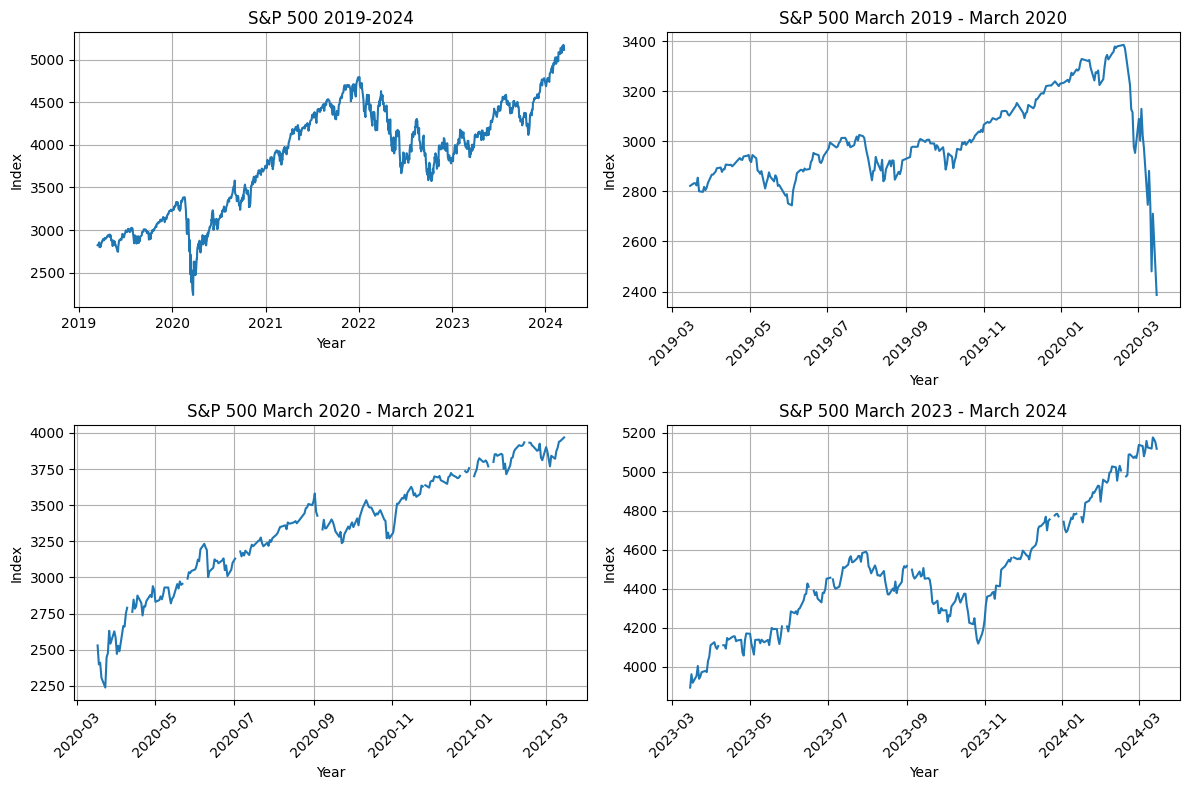

In [4]:
#plotting 4 graphs for each S&P 500
fig = plt.figure(figsize=(12,8))

#first graph will be the actual S&P 500
ax1 = fig.add_subplot(2,2,1)
ax1.plot(sp500.SP500)
ax1.grid()
ax1.set_title('S&P 500 2019-2024')
ax1.set_xlabel('Year')
ax1.set_ylabel('Index')

#second graph will be pre_covid
ax2 = fig.add_subplot(2,2,2)
ax2.plot(pre_covid.SP500)
ax2.grid()
ax2.set_title('S&P 500 March 2019 - March 2020')
ax2.set_xlabel('Year')
ax2.set_ylabel('Index')
ax2.tick_params(axis='x',labelrotation=45)

#third graph will be lockdown
ax3 = fig.add_subplot(2,2,3)
ax3.plot(lockdown.SP500)
ax3.grid()
ax3.set_title('S&P 500 March 2020 - March 2021')
ax3.set_xlabel('Year')
ax3.set_ylabel('Index')
ax3.tick_params(axis='x',labelrotation=45)

#fourth graph will be post_covid
ax4 = fig.add_subplot(2,2,4)
ax4.plot(post_covid.SP500)
ax4.grid()
ax4.set_title('S&P 500 March 2023 - March 2024')
ax4.set_xlabel('Year')
ax4.set_ylabel('Index')
ax4.tick_params(axis='x',labelrotation=45)

fig.tight_layout()

plt.savefig('sp500_four_graphs', dpi=300)


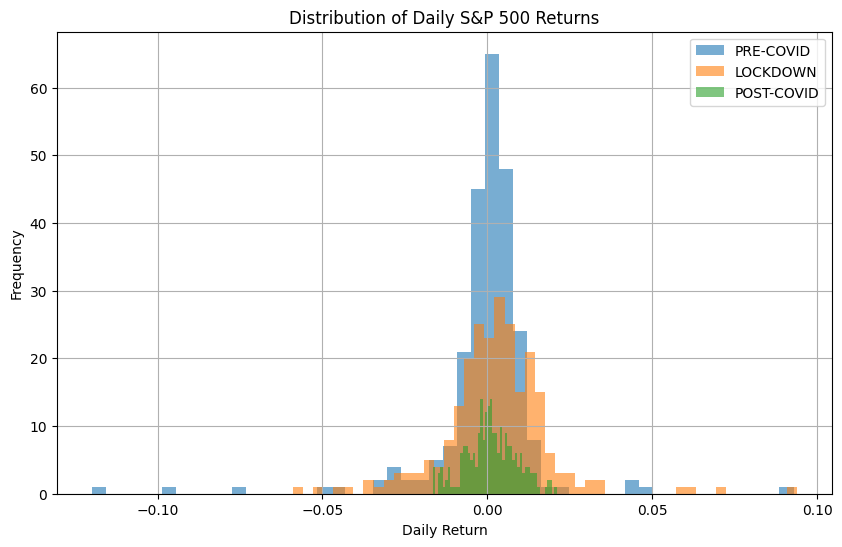

In [18]:
#histogram of daily returns
fig = plt.figure(figsize=(10,6))

ax5 = fig.add_subplot(1,1,1)
ax5.hist(pre_covid['daily_return'], bins=50,alpha=0.6,label='PRE-COVID')
ax5.hist(lockdown['daily_return'], bins=50,alpha=0.6,label='LOCKDOWN')
ax5.hist(post_covid['daily_return'], bins=50,alpha=0.6,label='POST-COVID')
ax5.grid()
ax5.set_title('Distribution of Daily S&P 500 Returns')
ax5.set_xlabel('Daily Return')
ax5.set_ylabel('Frequency')
ax5.legend()
plt.savefig('sp500_histogram', dpi=300)



# Interpretation of the Histogram

#### This histogram may seem confusing at first glance, but its shape makes sense once we consider the economic conditions during each period.

- Blue (Pre-COVID: March 14, 2019 – March 14, 2020)
The high volatility before the lockdown represents growing uncertainty in the global economy. Factors contributing to this include the emerging threat of the COVID-19 pandemic (lowering investor confidence), trade tensions between the U.S. and China, and disruptions to labor markets as remote work began and illness spread. These factors created heavy volatility, leading to larger fluctuations in the S&P 500’s daily returns.

- Orange (During Lockdown: March 15, 2020 – March 15, 2021)
Although this period began with a massive market crash in March 2020, the overall volatility appears lower when viewed across the entire year. This is due to the rapid monetary policy response, including stimulus checks and the Federal Reserve’s intervention,  which restored market confidence and stabilized prices. The early shock was followed by an unusually strong recovery, decreasing the measured volatility for this period.

- Green (Post-COVID: March 15, 2023 – March 15, 2024)
By this point, the market had largely stabilized. Investor confidence returned, inflation pressures began to ease, and businesses adapted to post-pandemic operations. As a result, daily fluctuations in the S&P 500 were minimal, showing a more stable and predictable economic environment.